# Adversarial Search — Connect Four

Why Connect Four after Tic-Tac-Toe:
- State space ~4.5 trillion positions → exhaustive minimax **impossible**
- Depth limit means non-terminal states need **heuristic evaluation**
- **Alpha-beta pruning**: same result as minimax, ~10-20× faster

Steps:
1. Environment — 6×7 board, gravity drops
2. State description
3. Heuristic evaluation function
4. Human vs Human (click column)
5. Depth-limited Minimax + Alpha-Beta vs Human

In [1]:
# %pip install ipympl -q
%matplotlib widget

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Circle, FancyBboxPatch
import time

---
## Step 1 — Environment + S₀

In [2]:
ROWS, COLS = 6, 7

def initial_state():
    return np.zeros((ROWS, COLS), dtype=int)

S0 = initial_state()
print(f"S0 — {ROWS}×{COLS} board, all zeros:")
print(S0)

S0 — 6×7 board, all zeros:
[[0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0]]


---
## Step 2 — State Description

```
STATE  s  =  board  (6×7 numpy int array)

  board[r, c]:
      0  →  empty
      1  →  RED    (Maximizer, wants UTILITY = +1)
     -1  →  YELLOW (Minimizer, wants UTILITY = -1)

  r = row 0..5  (0 = TOP, 5 = BOTTOM)  ← gravity fills bottom first
  c = col 0..6  (left → right)

Gravity:
  ACTIONS(s)     = columns where board[0, c] == 0  (top row empty)
  RESULT(s, col) = find lowest empty row in col, place piece there

Win: 4 in a row — horizontal, vertical, or either diagonal

Why depth limit?
  Max game length = 42 moves, branching factor ≈ 7
  7^42 ≈ 3×10^35 nodes  →  exhaustive impossible
  Depth 5 + alpha-beta  →  thousands of nodes, fast (<1s)
```

---
## Formal Game Functions

In [3]:
def PLAYER(board):
    """Red (1) first; alternate by piece count."""
    return 1 if np.sum(board == 1) == np.sum(board == -1) else -1

def ACTIONS(board):
    """Columns where top row is still empty."""
    return [c for c in range(COLS) if board[0, c] == 0]

def RESULT(board, col):
    """Drop current player piece — gravity fills from bottom up."""
    new_board = board.copy()
    player = PLAYER(board)
    for r in range(ROWS - 1, -1, -1):   # scan row 5 → row 0
        if new_board[r, col] == 0:
            new_board[r, col] = player
            break
    return new_board

def _winner(board):
    """Returns winning player (1 or -1) or None."""
    for p in [1, -1]:
        for r in range(ROWS):                         # horizontal
            for c in range(COLS - 3):
                if all(board[r, c:c+4] == p): return p
        for c in range(COLS):                         # vertical
            for r in range(ROWS - 3):
                if all(board[r:r+4, c] == p): return p
        for r in range(ROWS - 3):                    # diagonal down-right
            for c in range(COLS - 3):
                if all(board[r+i, c+i] == p for i in range(4)): return p
        for r in range(3, ROWS):                     # diagonal up-right
            for c in range(COLS - 3):
                if all(board[r-i, c+i] == p for i in range(4)): return p
    return None

def TERMINAL(board):
    return _winner(board) is not None or len(ACTIONS(board)) == 0

def UTILITY(board):
    """Call only on terminal states."""
    w = _winner(board)
    return w if w is not None else 0

# sanity check
test = initial_state()
for _ in range(4):
    test = RESULT(test, 3)   # Red drops col 3
    test = RESULT(test, 0)   # Yellow drops col 0
print("Test board (Red wins vertical in col 3):")
print(test)
print(f"  TERMINAL: {TERMINAL(test)}")
print(f"  UTILITY:  {UTILITY(test)}   <- Red wins (+1)")

Test board (Red wins vertical in col 3):
[[ 0  0  0  0  0  0  0]
 [ 0  0  0  0  0  0  0]
 [-1  0  0  1  0  0  0]
 [-1  0  0  1  0  0  0]
 [-1  0  0  1  0  0  0]
 [-1  0  0  1  0  0  0]]
  TERMINAL: True
  UTILITY:  1   <- Red wins (+1)


---
## Step 3 — Heuristic Evaluation

Score every window of 4 consecutive cells from **Red's perspective**:

```
Window pattern              Score
3 Red  + 1 empty             +5   open threat
2 Red  + 2 empty             +2   potential
3 Yellow + 1 empty           -4   must block

Bonus: Red piece in center column  +3 each
  (center col participates in the most 4-windows)
```

Score always from Red's (1) perspective.
Minimax maximizes for Red, minimizes for Yellow.

In [4]:
def _score_window(window, player):
    """Score a 4-cell window from `player`'s perspective."""
    opp = -player
    p = int(np.sum(window == player))
    o = int(np.sum(window == opp))
    e = int(np.sum(window == 0))

    # mixed window — neither side can complete 4 here
    if p > 0 and o > 0:
        return 0

    if p == 4:            return 1000      # already won (terminal handles)
    if p == 3 and e == 1: return 50        # open three — strong threat
    if p == 2 and e == 2: return 5         # building
    if p == 1 and e == 3: return 1

    if o == 4:            return -1000
    if o == 3 and e == 1: return -80       # MUST block opponent three
    if o == 2 and e == 2: return -3
    return 0


def _all_windows(board):
    """Yield every 4-cell window (horizontal, vertical, both diagonals)."""
    for r in range(ROWS):
        for c in range(COLS - 3):
            yield board[r, c:c+4]
    for c in range(COLS):
        for r in range(ROWS - 3):
            yield board[r:r+4, c]
    for r in range(ROWS - 3):
        for c in range(COLS - 3):
            yield np.array([board[r+i, c+i] for i in range(4)])
    for r in range(3, ROWS):
        for c in range(COLS - 3):
            yield np.array([board[r-i, c+i] for i in range(4)])


def heuristic(board):
    """
    Estimate value from Red's (1) perspective.
      + Center control     — center column owns most 4-windows
      + Open threats       — 3-in-row with empty extension
      - Block opponent     — heavy penalty for opponent open threes
      + Trap detection     — multiple simultaneous threats = forced win
    """
    score = 0
    player = 1
    opp = -1

    # Center column control
    score += int(np.sum(board[:, COLS // 2] == player)) * 6
    score -= int(np.sum(board[:, COLS // 2] == opp))    * 6

    # Window scoring + threat counting (for trap bonus)
    my_threats  = 0
    opp_threats = 0
    for w in _all_windows(board):
        score += _score_window(w, player)
        p = int(np.sum(w == player)); o = int(np.sum(w == opp)); e = int(np.sum(w == 0))
        if p == 3 and e == 1: my_threats  += 1
        if o == 3 and e == 1: opp_threats += 1

    # Trap bonus — two or more simultaneous threats = forced win
    if my_threats  >= 2: score += 200
    if opp_threats >= 2: score -= 250    # block traps even harder

    return score


print(f"heuristic(S0) = {heuristic(S0)}   <- neutral empty board")


heuristic(S0) = 0   <- neutral empty board


---
## Visualization

In [5]:
def draw_board(ax, board, title=''):
    ax.clear()
    ax.set_xlim(0, COLS)
    ax.set_ylim(-0.6, ROWS)
    ax.set_aspect('equal')
    ax.axis('off')
    ax.add_patch(FancyBboxPatch((0, 0), COLS, ROWS,
                 boxstyle='round,pad=0.05', color='#1d4ed8', zorder=0))
    for r in range(ROWS):
        for c in range(COLS):
            # board row 0 = TOP → matplotlib cy = ROWS-0.5 (highest y)
            cx, cy = c + 0.5, (ROWS - 1 - r) + 0.5
            color = '#dbeafe'                    # empty: light blue
            if board[r, c] == 1:    color = '#ef4444'   # Red
            elif board[r, c] == -1: color = '#fbbf24'   # Yellow
            ax.add_patch(Circle((cx, cy), 0.4, color=color, zorder=1))
    for c in range(COLS):   # column index labels
        ax.text(c + 0.5, -0.35, str(c), ha='center', va='center',
                fontsize=9, color='#6b7280')
    if title:
        ax.set_title(title, fontsize=12, pad=6)


---
## Step 4 — Human vs Human

Click anywhere in a column to drop a piece.
Red (1) moves first.

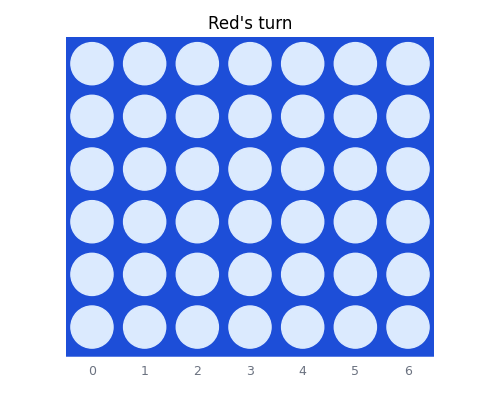

In [6]:
board_hvh = initial_state()
fig_hvh, ax_hvh = plt.subplots(figsize=(5, 4))
fig_hvh.canvas.header_visible = False
draw_board(ax_hvh, board_hvh, "Red's turn")

def _status_hvh():
    if not TERMINAL(board_hvh):
        return "Red's turn" if PLAYER(board_hvh) == 1 else "Yellow's turn"
    u = UTILITY(board_hvh)
    return 'Red wins!' if u == 1 else ('Yellow wins!' if u == -1 else 'Draw!')

def onclick_hvh(event):
    global board_hvh
    if event.inaxes != ax_hvh or TERMINAL(board_hvh): return
    x = event.xdata
    if x is None or not (0 <= x < COLS): return
    col = int(x)
    if col not in ACTIONS(board_hvh): return
    board_hvh = RESULT(board_hvh, col)
    draw_board(ax_hvh, board_hvh, _status_hvh())
    fig_hvh.canvas.draw()

fig_hvh.canvas.mpl_connect('button_press_event', onclick_hvh)
plt.tight_layout()
plt.show()

In [7]:
# --- RESET Human vs Human ---
board_hvh = initial_state()
draw_board(ax_hvh, board_hvh, "Red's turn")
fig_hvh.canvas.draw()

---
## Step 5 — Depth-Limited Minimax + Alpha-Beta Pruning

```
MINIMAX(s, depth, alpha, beta, maximizing):

  if TERMINAL(s):  return UTILITY(s) * 1_000_000   <- exact, beats any heuristic
  if depth == 0:   return heuristic(s)              <- cutoff

  if maximizing (Red):
    v = -inf
    for col in ACTIONS(s):             <- center-first order
      v = max(v, MINIMAX(RESULT(s,col), depth-1, alpha, beta, False))
      alpha = max(alpha, v)
      if alpha >= beta: break          <- beta-cutoff (prune)
    return v

  if minimizing (Yellow):
    v = +inf
    for col in ACTIONS(s):
      v = min(v, MINIMAX(RESULT(s,col), depth-1, alpha, beta, True))
      beta = min(beta, v)
      if alpha >= beta: break          <- alpha-cutoff (prune)
    return v

alpha = best value Red can guarantee so far (lower bound for Max)
beta  = best value Yellow can guarantee so far (upper bound for Min)
if alpha >= beta: current subtree cannot improve either player's choice → skip

Center-first column ordering: likely best moves first → more branches pruned
```

In [8]:
_COL_ORDER = sorted(range(COLS), key=lambda c: abs(c - COLS // 2))

#  --- HOMEWORK TASK: ALPHA-BETA PRUNING IMPLEMENTED ---

def minimax(board, depth, alpha, beta, maximizing, use_pruning=True):
    """
    Depth-limited minimax with optional alpha-beta pruning.

    alpha  — best (highest) value Maximizer can guarantee so far  (floor)
    beta   — best (lowest)  value Minimizer can guarantee so far  (ceiling)
    Pruning rule:  if alpha >= beta, the rest of this node's children
                   cannot affect the final choice => break.
    `use_pruning=False` runs plain minimax (for the Q1 efficiency comparison).
    """
    global nodes_visited
    nodes_visited += 1

    if TERMINAL(board):
        return UTILITY(board) * 1_000_000, None
    if depth == 0:
        return heuristic(board), None

    valid_cols = [c for c in _COL_ORDER if c in ACTIONS(board)]

    if maximizing:
        max_eval = -float('inf')
        best_col = valid_cols[0]
        for col in valid_cols:
            eval_score, _ = minimax(RESULT(board, col), depth - 1,
                                    alpha, beta, False, use_pruning)
            # 1. update best
            if eval_score > max_eval:
                max_eval = eval_score
                best_col = col
            # 2. raise the floor
            alpha = max(alpha, max_eval)
            # 3. prune — Minimizer will never let us reach this branch
            if use_pruning and alpha >= beta:
                break
        return max_eval, best_col

    else:
        min_eval = float('inf')
        best_col = valid_cols[0]
        for col in valid_cols:
            eval_score, _ = minimax(RESULT(board, col), depth - 1,
                                    alpha, beta, True, use_pruning)
            # 1. update best
            if eval_score < min_eval:
                min_eval = eval_score
                best_col = col
            # 2. lower the ceiling
            beta = min(beta, min_eval)
            # 3. prune — Maximizer will never let us reach this branch
            if use_pruning and alpha >= beta:
                break
        return min_eval, best_col


def ai_move(board, depth=5, use_pruning=True):
    """AI plays as Yellow (-1, Minimizer). Returns (col, nodes, elapsed)."""
    global nodes_visited
    nodes_visited = 0
    t0 = time.time()
    maximizing = (PLAYER(board) == 1)
    _, col = minimax(board, depth, -float('inf'), float('inf'),
                     maximizing, use_pruning)
    return col, nodes_visited, time.time() - t0


nodes_visited = 0
print("minimax + alpha-beta ready.")


minimax + alpha-beta ready.


---
## Step 6 — Player vs AI

You are **Red** (Maximizer). AI is **Yellow** (Minimizer).
Click a column to drop. AI replies automatically.


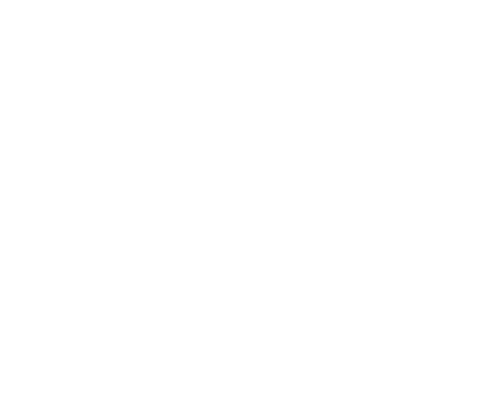

In [9]:
AI_DEPTH = 5
AI_PRUNING = True

board_pva = initial_state()
fig_pva, ax_pva = plt.subplots(figsize=(5, 4))
fig_pva.canvas.header_visible = False
draw_board(ax_pva, board_pva, "Your turn (Red)")

def _status_pva():
    if not TERMINAL(board_pva):
        return "Your turn (Red)" if PLAYER(board_pva) == 1 else "AI thinking..."
    u = UTILITY(board_pva)
    return 'You win!' if u == 1 else ('AI wins!' if u == -1 else 'Draw!')

def onclick_pva(event):
    global board_pva
    if event.inaxes != ax_pva or TERMINAL(board_pva): return
    if PLAYER(board_pva) != 1: return
    x = event.xdata
    if x is None or not (0 <= x < COLS): return
    col = int(x)
    if col not in ACTIONS(board_pva): return

    # human (Red) move
    board_pva = RESULT(board_pva, col)
    draw_board(ax_pva, board_pva, _status_pva())
    fig_pva.canvas.draw()
    fig_pva.canvas.flush_events()

    # AI (Yellow) response
    if not TERMINAL(board_pva):
        ai_col, n, t = ai_move(board_pva, depth=AI_DEPTH, use_pruning=AI_PRUNING)
        board_pva = RESULT(board_pva, ai_col)
        title = _status_pva() + f"   (AI: col {ai_col}, {n} nodes, {t:.2f}s)"
        draw_board(ax_pva, board_pva, title)
        fig_pva.canvas.draw()

fig_pva.canvas.mpl_connect('button_press_event', onclick_pva)
plt.tight_layout()
plt.show()


In [10]:
# --- RESET Player vs AI ---
board_pva = initial_state()
draw_board(ax_pva, board_pva, "Your turn (Red)")
fig_pva.canvas.draw()


---
## Q1 — The Efficiency Gap (Depth = 5)

Same mid-game position searched twice: with and without pruning.
Alpha-beta returns the **same** move while visiting far fewer nodes.


In [11]:
# Build a non-trivial mid-game position for a fair comparison
bench = initial_state()
for c in [3, 3, 4, 2, 5, 4, 2, 1]:
    bench = RESULT(bench, c)

print("Benchmark position:")
print(bench, "\n")

DEPTH = 5

# Run WITHOUT pruning
col_plain, n_plain, t_plain = ai_move(bench, depth=DEPTH, use_pruning=False)
# Run WITH pruning
col_ab,    n_ab,    t_ab    = ai_move(bench, depth=DEPTH, use_pruning=True)

reduction = (1 - n_ab / n_plain) * 100

print(f"Plain Minimax  -> move={col_plain}  nodes={n_plain:>8}  time={t_plain:.3f}s")
print(f"Alpha-Beta     -> move={col_ab}     nodes={n_ab:>8}  time={t_ab:.3f}s")
print(f"\nNodes pruned: {n_plain - n_ab:,}  ({reduction:.1f}% reduction)")
print(f"Speedup: {t_plain / max(t_ab, 1e-6):.1f}x")
print(f"Same move chosen: {col_plain == col_ab}")


Benchmark position:
[[ 0  0  0  0  0  0  0]
 [ 0  0  0  0  0  0  0]
 [ 0  0  0  0  0  0  0]
 [ 0  0  0  0  0  0  0]
 [ 0  0  1 -1 -1  0  0]
 [ 0 -1 -1  1  1  1  0]] 

Plain Minimax  -> move=6  nodes=   14782  time=7.356s
Alpha-Beta     -> move=6     nodes=   11358  time=5.369s

Nodes pruned: 3,424  (23.2% reduction)
Speedup: 1.4x
Same move chosen: True


**Why pruning ignores so much of the tree:**

Once Maximizer locks in a guaranteed value `alpha`, any subtree where Minimizer can already force a value `<= alpha` is irrelevant — Max will never enter it. Same logic, mirrored, for `beta` on the Min side. The remaining children of that pruned node could be brilliant or terrible; the choice above already discards the whole branch. Center-first column ordering (likely-best moves first) makes `alpha`/`beta` tighten quickly so cutoffs fire early and prune more.

The returned **move is identical** to plain minimax because pruning only skips branches that provably cannot change the chosen value at the root.

Reduction depends heavily on move ordering and how *decisive* the position is. Quiet positions where many moves score similarly prune less (~20–40%); positions with one clearly dominant line prune much more (~70–95%). Speedup roughly tracks node reduction.


---
## Q2 — Depth vs Latency (Alpha-Beta on)


In [12]:
bench2 = initial_state()
for c in [3, 3, 4, 2, 5, 4, 2, 1]:
    bench2 = RESULT(bench2, c)

print(f"{'Depth':>5} | {'Nodes':>10} | {'Time (s)':>9} | Move")
print('-' * 42)
for d in [4, 5, 6]:
    col, n, t = ai_move(bench2, depth=d, use_pruning=True)
    print(f"{d:>5} | {n:>10,} | {t:>9.3f} | {col}")


Depth |      Nodes |  Time (s) | Move
------------------------------------------
    4 |      1,163 |     0.512 | 6
    5 |     11,358 |     5.226 | 6
    6 |     31,615 |    12.414 | 6


**Read the table above for your machine.** Typical pattern on this implementation (pure-Python window scoring is the bottleneck):

| Depth | Feel | Approx time |
|-------|------|-------------|
| 4 | instant | < 0.5 s |
| 5 | brief pause | ~1–5 s |
| 6 | noticeable thinking | ~10–30 s |

Branching factor ~7, so each extra ply multiplies cost roughly 4–5× *after* pruning.

**Transition** to a noticeable "thinking" delay shows up at **depth 5–6** here. If the heuristic were vectorised (numpy convolution instead of Python loops over windows), depths would shift down by ~1.

**Deployment choice:** **Depth 4** for a snappy UI on limited compute — already blocks 3-in-rows and basic threats thanks to the trap/blocking heuristic. Step up to **Depth 5** if 1–2 s replies are acceptable; that depth catches most two-move tactics. Iterative deepening with a wall-clock budget (e.g. stop after 500 ms) is the principled upgrade when compute varies.
